# Overture — Transportation network (live)

Fetch routable road segments for a block and inspect their road classes. Transportation is heavily OpenStreetMap-derived, so expect `ODbL-1.0` rows.

In [1]:
LAT_LIM = [40.757, 40.759]  # [south, north]
LON_LIM = [-73.987, -73.984]  # [west, east] — a Times Square block
OUT = "_overture_out"

In [2]:
from earthlens.earthlens import EarthLens

paths = EarthLens(
    data_source="overture",
    dataset="transportation",
    variables=["segment"],
    aoi=[LON_LIM[0], LAT_LIM[0], LON_LIM[1], LAT_LIM[1]],
    path=OUT,
).download()
paths

2026-05-27 14:52:00 | INFO | pyramids.base.config | Logging is configured.


2026-05-27 14:52:00.837 | INFO     | earthlens.overture.backend:_fetch:377 - Fetching Overture 'segment' (theme 'transportation') for bbox (-73.987, 40.757, -73.984, 40.759) (release=latest)


C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\overture\src\earthlens\overture\collection.py:77: LicenseWarning: transportation/segment: 80 of 80 feature(s) are ODbL-1.0 (OSM-derived). ODbL-1.0 carries attribution and share-alike obligations that CDLA-Permissive-2.0 does not; honour them when redistributing these rows.
  warn_if_odbl(license_ids, label)
2026-05-27 14:52:40.033 | INFO     | earthlens.overture.backend:_fetch:386 - transportation/segment: wrote 80 feature(s) to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\overture\docs\examples\overture\_overture_out\overture_transportation_segment_latest.parquet


[WindowsPath('C:/gdrive/algorithms/remote-sensing/earthlens/.claude/worktrees/overture/docs/examples/overture/_overture_out/overture_transportation_segment_latest.parquet')]

In [3]:
import geopandas as gpd

gdf = gpd.read_parquet(paths[0])
print(len(gdf), 'segments;  geom', gdf.geometry.geom_type.unique())
gdf[['id', 'subtype', 'class', 'license_id']].head()

80 segments;  geom <ArrowStringArray>
['LineString']
Length: 1, dtype: str


,id,subtype,class,license_id
0,fa2f8191-70b5-49e4-9bd5-29ac326e3c75,rail,subway,ODbL-1.0
1,10a7f5d4-8df6-4d73-b465-b5bf85ee2775,rail,subway,ODbL-1.0
2,58e6d598-e714-4db6-a188-405ef143adcc,rail,subway,ODbL-1.0
3,9ebb72a7-7f73-4c7e-b376-b512af3e7eb2,rail,subway,ODbL-1.0
4,b670600d-60e3-4bba-813b-cf67efdde949,rail,subway,ODbL-1.0


Road segments by `class`:

In [4]:
gdf['class'].value_counts()

class
footway           39
subway            19
secondary          8
residential        5
pedestrian         4
service            2
standard_gauge     2
primary            1
Name: count, dtype: int64

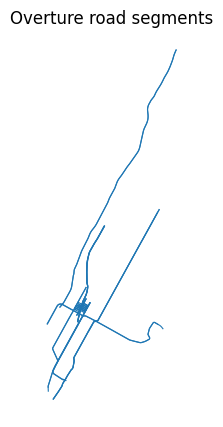

In [5]:
ax = gdf.plot(figsize=(5, 5), linewidth=0.8)
ax.set_title('Overture road segments')
ax.set_axis_off()